
# Data analysis in Astronomy 

### Homework 2 due 10/21 11:59 pm

### Name: B12202042 Cheng An, Hsieh
### Date   : 2024-10-20
### These codes used Githhub copilot to help me write the code. 

------------

# 1. (Monte Carlo Exercise) The variance of the sample variance

A sample of N data points drawn from a normal distribution has a variance. 
This variance also has a variance. 

Based on theoretical calculation, the variance of variance with N data points is 
$= \frac{2*\sigma^{4}}{N}$ where $\sigma$ is the standard deviation of the normal distribution.
 

### To do: 
### 1. write a code and use Monte Carlo method to validate the theoretical expection. (15 points)

### 2. Produce a plot with x-axis (N data point) and y-axis (variance of variance) with two curves showing a. your Monte Carlo simulation and b. theoretical calculation. (10 points)

(You can just use a normal distribution with mean=0 and sigma=10)

# --------------------------------------------

In [2]:
#import
import numpy as np 
import matplotlib.pyplot as plt
import astropy.io.fits as pf
import scipy.stats as ss
from scipy.optimize import curve_fit

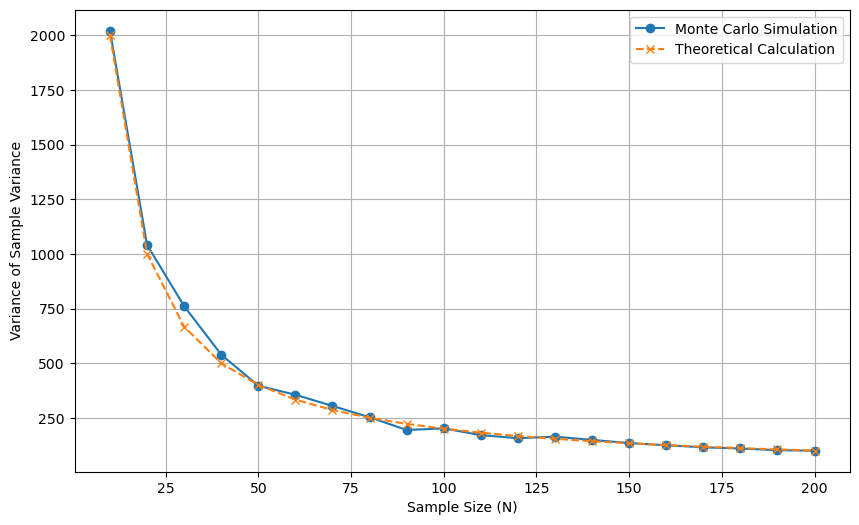

In [4]:
### 1. write a code and use Monte Carlo method to validate the theoretical expection. (15 points)

# Parameters
mu = 0
sigma = 10
num_simulations = 1000  # Number of simulations samples

# Sample sizes to consider
sample_sizes = np.arange(10, 201, 10)

# Monte Carlo simulation
MC_vars = []
theoretical_vars = []
for N in sample_sizes:
    sample_var = []
    for i in range(num_simulations):
        sample = np.random.normal(mu, sigma, N)
        sample_var.append(np.var(sample, ddof=1))
    MC_vars.append(np.var(sample_var, ddof=1))
    # Theoretical calculation
    theoretical_vars.append((2 * sigma**4) / N)


### 2. Produce a plot with x-axis (N data point) and y-axis (variance of variance) with two curves showing a. your Monte Carlo simulation and b. theoretical calculation. (10 points)
# Plot
plt.figure(figsize=(10, 6))
plt.plot(sample_sizes, MC_vars, label='Monte Carlo Simulation', marker='o')
plt.plot(sample_sizes, theoretical_vars, label='Theoretical Calculation', linestyle='--', marker='x')
plt.xlabel('Sample Size (N)')
plt.ylabel('Variance of Sample Variance')
plt.legend()
plt.grid(True)
plt.show()

# 2. When the central limit theorem breaks down 

The central limit theorem states that given a sample with N data points drawn from some distributions with mean $\mu$ and standard deviation $\sigma$, the precision of the mean of the sample will scale with sigma/sqrt(N).

In other words, if you have a larger sample, you can obtain a more precise estimation of the mean value. 

However, this is not always true. 
### To do:
### a. Find a distribution that will break the central limit theorem and write a code using Monte Carlo method to show that the standard error of the mean does not decrease wtih 1/N^{2}. (15 points)


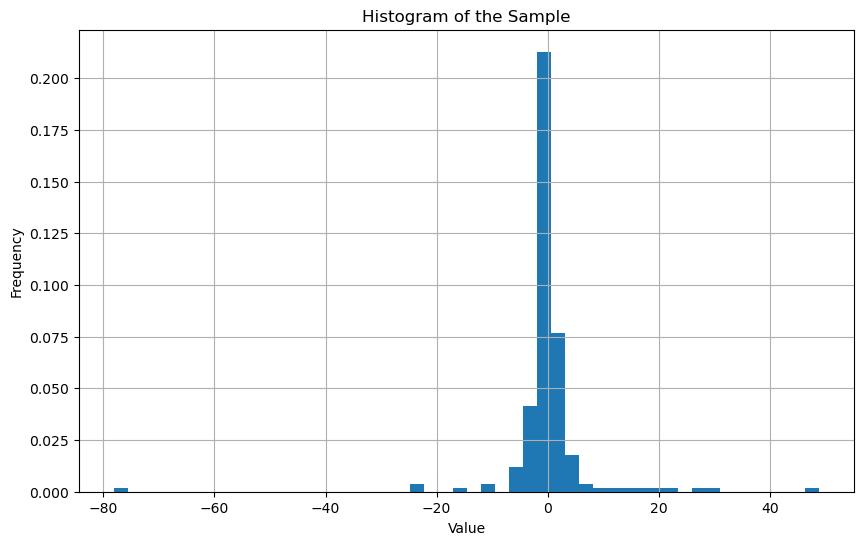

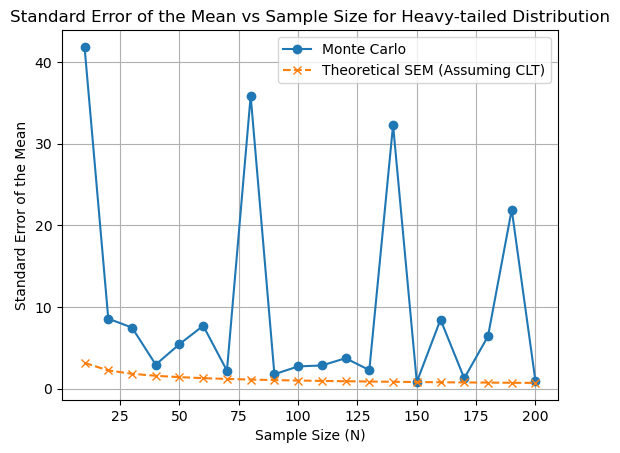

In [9]:
### a. Find a distribution that will break the central limit theorem and write a code using Monte Carlo method to show that the standard error of the mean does not decrease wtih 1/N^{2}. (15 points)

# Parameters
mu = 0
sigma = 10
num_simulations = 1000  # Number of simulations samples

# Sample sizes to consider
sample_sizes = np.arange(10, 201, 10)

# Monte Carlo simulation
MC_errs = []
theoretical_errs = []

def sample_func(N):
    """If the sample do not use mu and sigma to generate,
    the central limit theorem will not hold. At here we use t-distribution to show that the standard error does not decrease with 1/N^2"""
    
    return np.random.standard_t(df= 1, size = N)  # t-distribution with df=1

for N in sample_sizes:
    sample_means = []
    for _ in range(num_simulations):
        sample = sample_func(N)
        sample_mean = np.mean(sample)
        sample_means.append(sample_mean)

    # Calculate standard error of the mean
    standard_error = np.std(sample_means, ddof=1)/np.sqrt(N)
    MC_errs.append(standard_error)
    
    # Theoretical standard error 
    theoretical_sem = sigma /np.sqrt(N)
    theoretical_errs.append(theoretical_sem)


# Plot the distribution example
plt.figure(figsize=(10, 6))
plt.hist(sample, bins=50, density=True)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of the Sample')
plt.grid(True)
plt.show()

#Plot the error vs sample size
plt.plot(sample_sizes, MC_errs, label='Monte Carlo ', marker='o')
plt.plot(sample_sizes, theoretical_errs, label='Theoretical SEM (Assuming CLT)', linestyle='--', marker='x')
plt.xlabel('Sample Size (N)')
plt.ylabel('Standard Error of the Mean')
plt.title('Standard Error of the Mean vs Sample Size for Heavy-tailed Distribution')
plt.legend()
plt.grid(True)
plt.show()


# --------------------------------------------

# 3. Reproduce Figure 1 in Menard and Chelouche (2009)

The data used in Menard and Cheloudche (2009) can be found at https://www.dropbox.com/s/czoqbe4jh70sdry/Rao_et_al.fits?dl=0 (The data is from Rao et al. (2006))

# Column $N_H == log10(N_{HI})$ and $EW2796 == W^{2796}_{0}(MgII)$

### To do:
### Use the data to reproduce the arithmetic, geomtric, and median values of $N_{HI}$ as a function of $W^{2796}_{0}(MgII)$ and include the bootstrap error
### Make a plot showing your results
### (25 points)

# --------------------------------------------


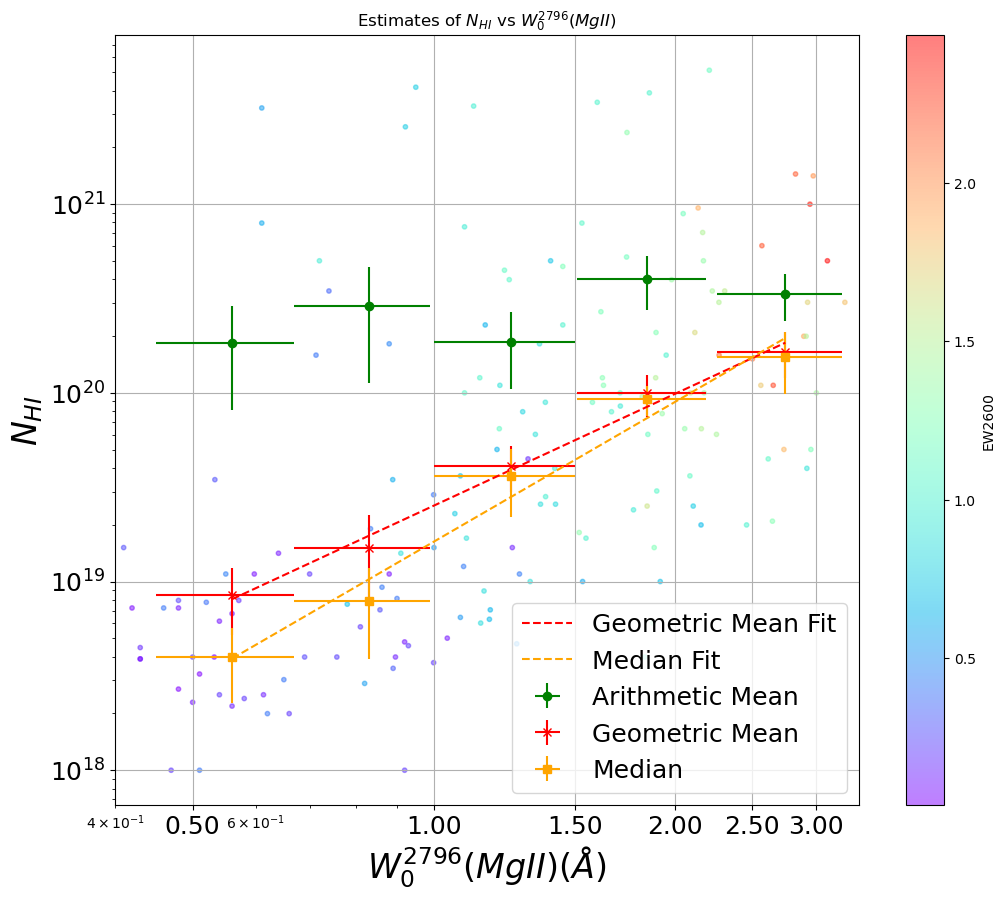

In [8]:
### Use the data to reproduce the arithmetic, geometric, and median values of $N_{HI}$ as a function of $W^{2796}_{0}(MgII)$ and include the bootstrap error

# Load data from FITS file
path = 'Rao_et_al.fits'
hdul = pf.open(path)
data = hdul[1].data
#print(data.columns)
hdul.close()

# Extracting the data
EW2600 = data['EW2600']
EW2796 = data['EW2796']
NHI = 10 ** data['logN'] 


# Define the bootstrap resampling function
"""use float128 to avoid overflow error"""
def resample(data):
    return np.float128(np.random.choice(data, size=len(data), replace=True))


# Define functions to calculate arithmetic, geometric, and median values with bootstrap errors

def arithmetic_mean(x, n=1000):
    x = np.array(x)
    boot_means = [np.mean(resample(x)) for _ in range(n)]
    return np.mean(x), np.std(boot_means, ddof=1)

def geometric_mean(x, n=1000):
    x = np.array(x)
    x = x[x > 0]  # Remove non-positive values
    boot_means = []
    for _ in range(n):
        resample_data = resample(x)
        boot_means.append(np.exp(np.mean(np.log(resample_data))))
    return np.exp(np.mean(np.log(x))), np.std(boot_means, ddof=1) 

def median(x, n=1000):
    x = np.array(x)
    boot_medians = [np.median(resample(x)) for _ in range(n)]
    return np.median(x), np.std(boot_medians, ddof=1)

# Fit the geometric mean and median
def fit_func(x, a, b):
    return a * x + b

# Bins and x-error values
bins = [0.56, 0.83, 1.25, 1.85, 2.75]  # Copied from paper
xerr = [0.45, 0.67, 1.00, 1.51, 2.26]  # Copied from paper too

# Store results
arithmetic_mean_NHIs = []
geometric_mean_NHIs = []
median_NHIs = []
arithmetic_bootstrap_errors = []
geometric_bootstrap_errors = []
median_bootstrap_errors = []
xerrs = []

# Calculate means and bootstrap errors for each bin
for i in range(len(bins)):
    xerrs.append(bins[i] - xerr[i])
    data_bins = data[(data['EW2796'] > (bins[i] - xerrs[i])) & (data['EW2796'] < (bins[i] + xerrs[i])) & (data['logN'] > 0)]
    NHI_bins = 10 ** np.array(data_bins['logN'])
    
    if len(NHI_bins) == 0:
        continue
    
    arithmetic_mean_NHI, a_boot = arithmetic_mean(NHI_bins)
    geometric_mean_NHI, g_boot = geometric_mean(NHI_bins)
    median_NHI, m_boot = median(NHI_bins)
    
    arithmetic_mean_NHIs.append(arithmetic_mean_NHI)
    geometric_mean_NHIs.append(geometric_mean_NHI)
    median_NHIs.append(median_NHI)
    arithmetic_bootstrap_errors.append(a_boot)
    geometric_bootstrap_errors.append(g_boot)
    median_bootstrap_errors.append(m_boot)
    

    

# Fit geometric mean
popt_geo, pcov_geo = curve_fit(fit_func, np.log10(bins), np.log10(geometric_mean_NHIs))
geo_fit = fit_func(np.log10(bins), *popt_geo)

# Fit median
popt_med, pcov_med = curve_fit(fit_func, np.log10(bins), np.log10(median_NHIs))
med_fit = fit_func(np.log10(bins), *popt_med)

# Define x-ticks
xticks = np.linspace(0.5, 3, 6)

# Define color based on EW2600 
colors = EW2600

# Plotting the results
plt.figure(figsize=(12, 10))
sc = plt.scatter(EW2796, NHI, s=10, c=colors, cmap='rainbow', alpha=0.5)
plt.colorbar(sc, label='EW2600')
plt.errorbar(bins, arithmetic_mean_NHIs, yerr=arithmetic_bootstrap_errors, xerr=xerrs, fmt='o', label='Arithmetic Mean', color='green')
plt.errorbar(bins, geometric_mean_NHIs, yerr=geometric_bootstrap_errors, xerr=xerrs, fmt='x', label='Geometric Mean', color='red')
plt.errorbar(bins, median_NHIs, yerr=median_bootstrap_errors, xerr=xerrs, fmt='s', label='Median', color='orange')
plt.plot(bins, 10**geo_fit, label='Geometric Mean Fit', linestyle='--', color='red')
plt.plot(bins, 10**med_fit, label='Median Fit', linestyle='--', color='orange')
plt.xscale('log')
plt.yscale('log')
plt.xticks(xticks, [f'{x:.2f}' for x in xticks])
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel(r'$W^{2796}_{0}(MgII)$($\AA$)', fontsize=24)
plt.xlim(0.4, 3.4)
plt.ylabel(r'$N_{HI}$', fontsize=24)
plt.title(r'Estimates of $N_{HI}$ vs $W^{2796}_{0}(MgII)$')
plt.legend(fontsize= 18)
plt.grid(True)
plt.show()


# Discussion the diff with papers
- I use the same bins for all statistic, I don't know why the paper use the different bins, maybe they want to show their error bars more significant.

- the second bin of median doesn't show the large error bar, this may because the different boostrap times, the other error bars is similar.

- I do not show the limit dots of W2600.



# 4. Finishing your Pearson and Spearman correlation coefficients calculation

In class, you have learned how to calculate Pearson correlation coefficientts.
### https://www.dropbox.com/s/h7545q0vzcqhi38/sky_maps_new_64_v6.fits?dl=0
### To do: 
### a. Finish your Pearson and Spearman correlation coefficient code (10 points)
### b. Finish your code of using the bootstrap method to estimate the uncertainty of the Pearson and Spearman coefficients for (EBV, HI), (EBV, H2), and (EBV, H_total) (15 points)

### Print out your results

In [9]:

ISM = pf.getdata('Sky_Maps_v6.fits',1)

EBV = ISM['SFD']
HI = ISM['HI']/1e21

conversion_factor = 2*1e20/1e21
H2 = ISM['CO10']*conversion_factor

In [10]:
# define pearsonr function
def your_pearsonr(x,y):
    
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_std = np.std(x)
    y_std = np.std(y)
    nx = len(x)
    ny = len(y)
    cov = np.sum((x - x_mean)*(y - y_mean))/(nx)

    if nx != ny:
        raise ValueError("x and y must have the same length")
    
    r = cov / (x_std * y_std)
    
    return  r

r = round(your_pearsonr(EBV,HI), 2)
r2 =  round(your_pearsonr(EBV,H2), 2)

r_sci= round(ss.pearsonr(EBV, HI)[0], 2) 
r_sci2 = round(ss.pearsonr(EBV, H2)[0], 2)


In [11]:
# Define merge sort function
def mergeSort(nums):
    if len(nums) < 2:
        return nums, list(range(len(nums)))
    mid = len(nums) // 2
    left, left_index = mergeSort(nums[:mid])
    right, right_index = mergeSort(nums[mid:])

    i = j = 0
    result = []
    index = []
    while i < len(left) and j < len(right):
        if left[i] < right[j]: 
            result.append(left[i])
            index.append(left_index[i])
            i += 1
        else: 
            result.append(right[j])
            index.append(right_index[j] + mid)
            j += 1

    while i < len(left): 
        result.append(left[i])
        index.append(left_index[i])
        i += 1

    while j < len(right): 
        result.append(right[j])
        index.append(right_index[j] + mid)
        j += 1

    return result, index

# Define get rank function
def get_rank(data):
    sorted_data, sorted_index = mergeSort(data)
    rank = [0] * len(data)
    for i, idx in enumerate(sorted_index):
        rank[idx] = i + 1
    return rank

def your_spearman(x,y):
    
    x_rank = get_rank(x)
    y_rank = get_rank(y)
    x_mean = np.mean(x_rank)
    y_mean = np.mean(y_rank)
    nx = len(x_rank)
    cov_rank = np.sum((x_rank - x_mean)*(y_rank - y_mean))/(nx)

    nx = len(x)

    spearman_correlation_coefficient = cov_rank / (np.std(x_rank) * np.std(y_rank))

    return spearman_correlation_coefficient

s_sci = round(ss.spearmanr(EBV, HI)[0], 2)
s_sci2 = round(ss.spearmanr(EBV, H2)[0], 2)
spearman_HI = round(your_spearman(EBV, HI), 2)
spearman_H2 = round(your_spearman(EBV, H2), 2)


In [12]:

# Define bootstrapping errors for r
def bootstrap_pearson(x, y, n=1000):
    r_values = []
    for _ in range(n):
        indices = np.random.randint(0, len(x), len(x))
        x_boot = x[indices]
        y_boot = y[indices]
        r, _ = ss.pearsonr(x_boot, y_boot)
        r_values.append(r)
    return np.std(r_values)

# Define bootstrapping errors for s
def bootstrap_spearman(x, y, n=1000):
    r_values = []
    for _ in range(n):
        indices = np.random.randint(0, len(x), len(x))
        x_boot = x[indices]
        y_boot = y[indices]
        r, _ = ss.spearmanr(x_boot, y_boot)
        r_values.append(r)
    return np.std(r_values)

# Calculate bootstrapping errors for r and s
r_boot_HI = bootstrap_pearson(EBV, HI)
r_boot_H2 = bootstrap_pearson(EBV, H2)
s_boot_HI = bootstrap_spearman(EBV, HI)
s_boot_H2 = bootstrap_spearman(EBV, H2)

In [13]:
r_boot_H2 = round(r_boot_H2, 2)
r_boot_HI = round(r_boot_HI, 2)
s_boot_H2 = round(s_boot_H2, 4)
s_boot_HI = round(s_boot_HI, 4)

print(f'EBV and HI, r = {r} +/- {r_boot_HI}, Scipy = {r_sci}')
print(f'EBV and H2, r = {r2} +/- {r_boot_H2}, Scipy = {r_sci2}')
print(f'Spearman correlation coefficient (EBV, HI): {spearman_HI} +/- {s_boot_HI}, Scipy = {s_sci}')
print(f'Spearman correlation coefficient (EBV, H2): {spearman_H2} +/- {s_boot_H2}, Scipy = {s_sci2}')


EBV and HI, r = 0.77 +/- 0.02, Scipy = 0.77
EBV and H2, r = 0.87 +/- 0.02, Scipy = 0.87
Spearman correlation coefficient (EBV, HI): 0.98 +/- 0.0003, Scipy = 0.98
Spearman correlation coefficient (EBV, H2): 0.36 +/- 0.0048, Scipy = 0.36


# --------------------------------------------

# 5. The effect of noise on the Pearson and Spearman correlation coefficients

In class, we mentioned that the measurement errors will affect the coefficient values. 

### To do:
### Changing the "noise_level" and observe the change of Pearson coefficient values 
### a) Make a plot with the noise_level from 0 to 100 as the x-axis and the Pearson coefficient values as the y-axis (with uncertainty estimated via bootrap) (10 points)

In [14]:
a = 1
b = 2
x = np.arange(0,10,0.2)


noise_level = 0 # change this and calculate Pearson coefficient 

noise_array = np.random.normal(0,noise_level,len(x))
y = a*x+b
y_obs = y+noise_array

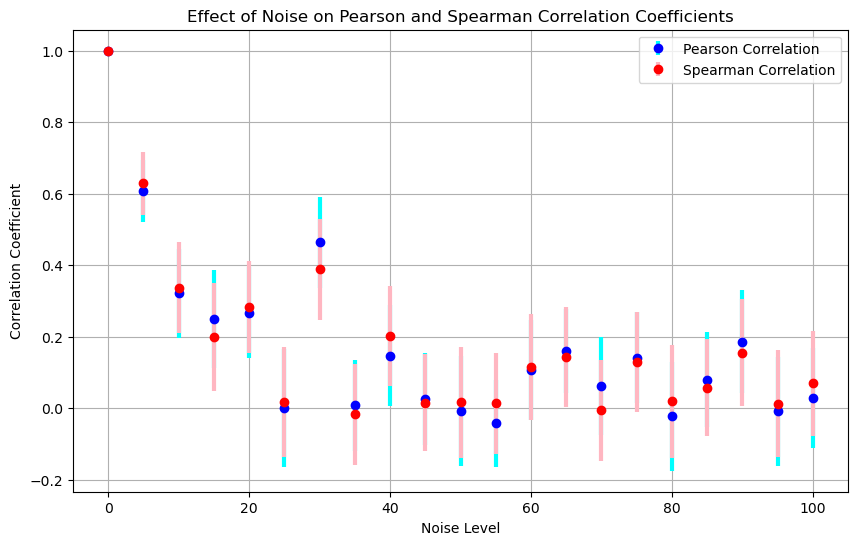

In [15]:

# Noise levels
noise_levels = np.linspace(0, 100, 21)
pearson_corrs = []
pearson_errs = []
spearman_corrs = []
spearman_errs = []

# Calculate Pearson and Spearman correlation for different noise levels
for noise_level in noise_levels:
    y_obs = y + np.random.normal(0, noise_level, size=len(x))
    pearson_corr = your_pearsonr(x, y_obs)
    pearson_err = bootstrap_pearson(x, y_obs)
    spearman_corr = your_spearman(x, y_obs)
    spearman_err = bootstrap_spearman(x, y_obs)
    
    pearson_corrs.append(pearson_corr)
    pearson_errs.append(pearson_err)
    spearman_corrs.append(spearman_corr)
    spearman_errs.append(spearman_err)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.errorbar(noise_levels, pearson_corrs, yerr=pearson_errs, fmt='o', color='blue', ecolor='cyan', elinewidth=3, capsize=0, label='Pearson Correlation')
plt.errorbar(noise_levels, spearman_corrs, yerr=spearman_errs, fmt='o', color='red', ecolor='lightpink', elinewidth=3, capsize=0, label='Spearman Correlation')
plt.xlabel('Noise Level')
plt.ylabel('Correlation Coefficient')
plt.title('Effect of Noise on Pearson and Spearman Correlation Coefficients')
plt.legend()
plt.grid(True)
plt.show()

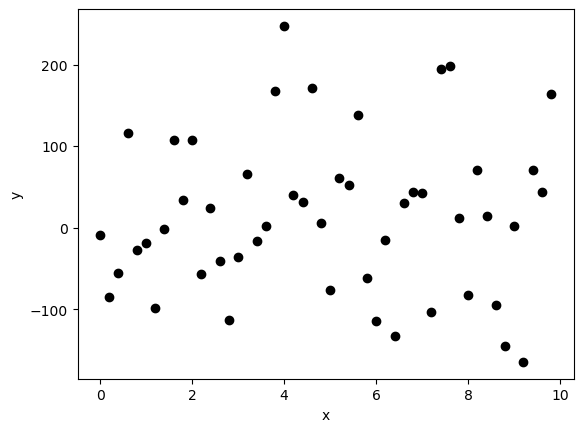

Pearson Correlation Coefficient:0.029


In [20]:
#plot the data to check with the results
plt.errorbar(x,y_obs,yerr=noise_array,ls='',lw=5)
plt.scatter(x, y_obs, color='black')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
print('Pearson Correlation Coefficient:%0.3f' % (your_pearsonr(x,y_obs)))